In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier

In [2]:
movie=pd.read_csv('joined_dataset.csv')
movie.head(5)

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,...,vote_count,movie_id,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",...,235.0,19995,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",...,235.0,206647,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
2,2,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,...,235.0,49026,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
3,3,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,...,235.0,49529,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel
4,4,15000000.0,"Animation,Family",38757.0,"hostage,magic,horse,fairy tale,musical,princes...",en,When the kingdom's most wanted-and most charmi...,48.681969,"Walt Disney Pictures,Walt Disney Animation Stu...",United States of America,...,235.0,38757,"Zachary Levi,Mandy Moore,Donna Murphy,Ron Perl...",Byron Howard,Tim Mertens,Douglas Rogers,David Goetz,Unknown,Alan Menken,Unknown


In [3]:
movie.drop(columns=['Unnamed: 0'], inplace=True)

# Predicting revenue using budget

In [4]:
X = movie[['budget']]
y = movie['revenue']

corr = movie['budget'].corr(movie['revenue'])
print("Correlation between Budget and Revenue:", round(corr, 3))


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Simple Linear Regression Results ===")
print("R² Score:", round(r2, 3))
print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))


print("\nIntercept:", round(model.intercept_, 2))
print("Coefficient (Budget):", round(model.coef_[0], 4))


Correlation between Budget and Revenue: 0.487

=== Simple Linear Regression Results ===
R² Score: 0.242
Mean Absolute Error: 33785510.05
Root Mean Squared Error: 49006607.8

Intercept: 14389711.3
Coefficient (Budget): 1.1121


# Predicting movie revenue using multiple linear regression

In [7]:
movie['release_month'] = pd.to_datetime(movie['release_date'], errors='coerce').dt.month.fillna(1).astype(int)
movie['cast_size'] = movie['cast'].apply(lambda x: len([c for c in str(x).split(',') if str(c).strip() != '']))
movie['genres_list'] = movie['genres'].apply(lambda x: [g.strip() for g in str(x).split(',') if g.strip() != ''])
movie['genre_count'] = movie['genres_list'].apply(len)


le_country = LabelEncoder()
movie['production_country_encoded'] = le_country.fit_transform(movie['production_countries'].astype(str))

le_company = LabelEncoder()
movie['production_company_encoded'] = le_company.fit_transform(movie['production_companies'].astype(str))

le_lang = LabelEncoder()
movie['language_encoded'] = le_lang.fit_transform(movie['original_language'].astype(str))


features = ['budget', 'runtime', 'release_month', 'cast_size', 'genre_count','production_country_encoded', 'production_company_encoded', 'language_encoded']
X = movie[features]
y = movie['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


=== Model Evaluation ===
Mean Absolute Error (MAE): 31506576.530
Root Mean Squared Error (RMSE): 2022167750682147.500
R² Score: 0.260


# Predicting High-revenue Movies Using Suitable Features

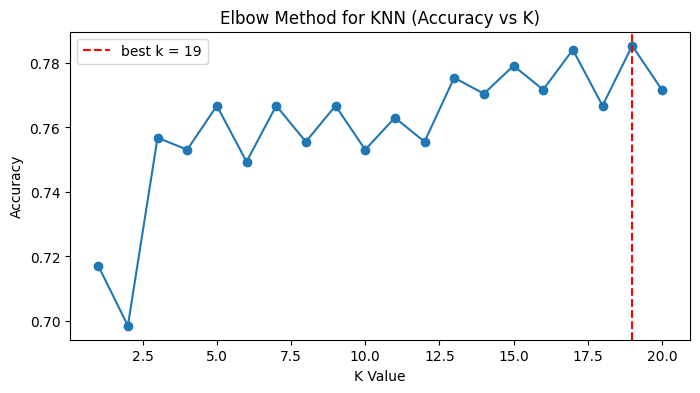

Best k (by test accuracy) = 19
Model Accuracy Score: 0.785
Model Precision Score: 0.788
Model Recall Score: 0.785
Model f1 Score: 0.786


In [13]:
movie['high_revenue'] = (movie['revenue'] > movie['revenue'].median()).astype(int)
movie['release_month'] = pd.to_datetime(movie['release_date'], errors='coerce').dt.month.fillna(1).astype(int)
movie['cast_size'] = movie['cast'].apply(lambda x: len([c for c in str(x).split(',') if str(c).strip() != '']))
movie['genres_list'] = movie['genres'].apply(lambda x: [g.strip() for g in str(x).split(',') if g.strip() != ''])
movie['genre_count'] = movie['genres_list'].apply(len)


le_country = LabelEncoder()
movie['production_country_encoded'] = le_country.fit_transform(movie['production_countries'].astype(str))

le_company = LabelEncoder()
movie['production_company_encoded'] = le_company.fit_transform(movie['production_companies'].astype(str))

le_lang = LabelEncoder()
movie['language_encoded'] = le_lang.fit_transform(movie['original_language'].astype(str))


features = ['budget', 'runtime', 'release_month', 'cast_size', 'genre_count','production_country_encoded', 'production_company_encoded', 'language_encoded']
X = movie[features]
y = movie['high_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

accuracy = []
k_range = range(1, 21)
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    accuracy.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8,4))
plt.plot(list(k_range), accuracy, marker='o')
best_k = int(np.argmax(accuracy) + 1)
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Elbow Method for KNN (Accuracy vs K)')
plt.legend()
plt.show()

print(f"Best k (by test accuracy) = {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy Score: {acc:.3f}")

pre = precision_score(y_test, y_pred,average='weighted')
print(f"Model Precision Score: {pre:.3f}")

rec = recall_score(y_test, y_pred,average='weighted')
print(f"Model Recall Score: {rec:.3f}")

f1 = f1_score(y_test, y_pred,average='weighted')
print(f"Model f1 Score: {f1:.3f}")

